## Introduction


With the rapid growth of e-commerce platforms and mobile applications, customers frequently share their opinions through product reviews. These reviews contain valuable insights that help businesses understand customer satisfaction, identify product issues, and improve overall product quality. However, manually analyzing thousands of reviews is time-consuming and inefficient.

Natural Language Processing (NLP) and Deep Learning techniques can be used to automatically analyze large volumes of text data and extract meaningful insights from customer feedback. Sentiment analysis is one of the most common NLP tasks used to classify text into different sentiment categories such as positive, neutral, or negative.

This project builds an AI-powered product review analyzer that automatically predicts the sentiment of customer reviews using a deep learning model developed with TensorFlow. The system processes textual reviews, cleans and transforms the data, and trains a neural network model capable of identifying the emotional tone expressed in the review.

## Objective

The main objective of this project is to develop an automated system that can analyze product reviews and determine whether the sentiment expressed by the customer is positive, neutral, or negative.

The key goals of the project include:

• Performing data preprocessing and cleaning on raw review text.
• Conducting exploratory data analysis (EDA) to understand review patterns.
• Applying Natural Language Processing (NLP) techniques such as tokenization and sequence padding.
• Building and training a deep learning sentiment classification model using TensorFlow.
• Evaluating the model's performance using appropriate metrics.
• Deploying the trained model as an interactive web application using Streamlit where users can input a review and instantly receive a sentiment prediction.

This system demonstrates how machine learning and NLP techniques can be applied to extract actionable insights from customer feedback, helping businesses make data-driven decisions.

## Sentiment Analysis

In [27]:
# Importing the required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

In this step, the necessary libraries for data processing, text preprocessing, and deep learning are imported.

In [3]:
# Loading the dataset containing Amazon product reviews
df=pd.read_csv('amazon_reviews.csv')

In [4]:
# Display the first 5 rows of the dataset
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,7aaec689-8e11-4c54-a8f7-5d9a179fb9f0,Myria Kasapi,Amazon has put restrictions on me downloading ...,1,0,32.6.0.100,2026-03-19 09:52:07,32.6.0.100
1,b4968821-fd9a-49c6-a9f2-75846cd952ec,Mohamed Mime,أسوء خدمة تصويل وخدمة عملاء في الامارات كلها ا...,1,0,NaN,2026-03-19 08:24:29,NaN
2,7525ff96-71fc-4025-bac1-d9a785540d8f,Melissa Schalski,it's a good shopping app to use,5,0,32.5.0.100,2026-03-19 08:15:24,32.5.0.100
3,91c33eb5-be15-4390-9981-490987feb9f6,crazy DJ,i am trying to contact customer service but th...,1,0,NaN,2026-03-19 07:30:41,NaN
4,8a431158-5595-45c8-bfc3-a07ad3995a4d,DJ Witmer,Samsung Galaxy tablet s10 + not able to downlo...,1,0,32.5.0.100,2026-03-19 07:26:45,32.5.0.100


The original dataset contains multiple columns such as user information, timestamps, and application version details.
However, for sentiment analysis, only the review text and the rating score are required.

In [5]:
# Selecting only the relevant columns required for sentiment analysis
df = df[['content','score']]

In [6]:
# Renaming the columns to more readable names
df.columns = ['review','rating']

df.head()

,review,rating
0,Amazon has put restrictions on me downloading ...,1
1,أسوء خدمة تصويل وخدمة عملاء في الامارات كلها ا...,1
2,it's a good shopping app to use,5
3,i am trying to contact customer service but th...,1
4,Samsung Galaxy tablet s10 + not able to downlo...,1


In [7]:
# Check dataset shape after column selection
df.shape

(85598, 2)

There are about 85598 rows.

In [8]:
# Checking the missing values in the dataset
df.isnull().sum()

review    6
rating    0
dtype: int64

In [9]:
# Removing rows that contain missing values in the dataset
df = df.dropna()
# Check the dataset after removing missing values
df.shape

(85592, 2)

In [10]:
# Function to convert rating scores into sentiment categories
def sentiment_label(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

# Applying the function to create a new column called 'sentiment'
df['sentiment'] = df['rating'].apply(sentiment_label)

The dataset contains numerical rating scores ranging from 1 to 5. However, for sentiment analysis, it is more useful to convert these numerical values into sentiment categories.

In [11]:
# Count the number of reviews in each sentiment category
df['sentiment'].value_counts()

sentiment
Negative    48215
Positive    30382
Neutral      6995
Name: count, dtype: int64

The sentiment distribution shows that negative reviews are the most frequent, followed by positive reviews, while neutral reviews appear much less frequently.
This indicates that the dataset is imbalanced, with significantly fewer neutral reviews compared to the other classes.
Such imbalance can influence model training, as the model may become biased toward predicting the more frequent classes.

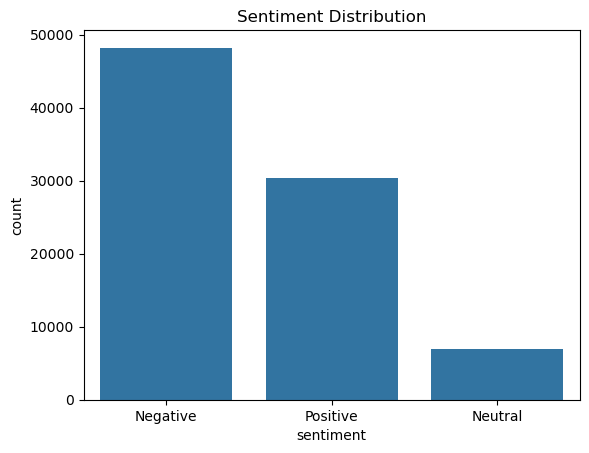

In [12]:
# Visualizing the distribution of sentiment classes in the dataset
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

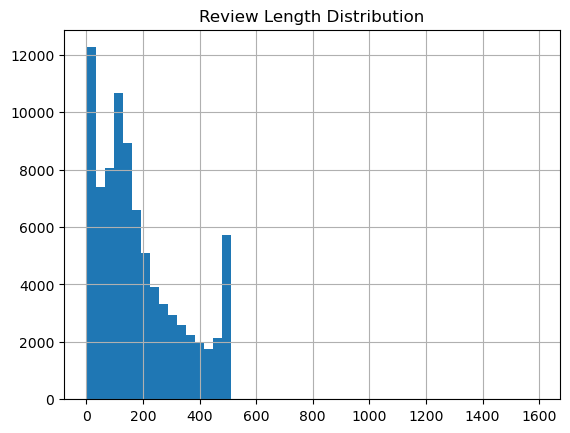

In [13]:
# Calculate the length of each review (number of characters)
df['review_length'] = df['review'].apply(len)

# Plot a histogram to visualize the distribution of review lengths
df['review_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

The histogram shows that most reviews are relatively short, with the majority of review lengths concentrated below 200 characters. A smaller number of reviews are longer and contain more detailed feedback.

In [14]:
nltk.download('stopwords')
nltk.download('punkt')

# Creating a set of English stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


After downloading the necessary resources, a set of English stopwords is created. This set will be used during text preprocessing to remove common words that do not carry important sentiment information. This step helps improve the quality of the text data before it is converted into numerical features for model training.

In [15]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

This function cleans and preprocesses text data before applying Natural Language Processing (NLP) techniques.
It converts text to lowercase, removes URLs and special characters, filters out stopwords, and returns a cleaned version of the text.
This process helps reduce noise in the dataset and improves the performance of machine learning models used for sentiment analysis or text classification.

In [16]:
# Apply the function to each review
df['clean_review'] = df['review'].apply(clean_text)

In [17]:
# Convert sentiment labels (text) into numerical values
df['sentiment'] = df['sentiment'].map({
    'Negative':0,
    'Neutral':1,
    'Positive':2
})

In [18]:
# Split the dataset into training data(80%) and testing data(20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [28]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.5921630690466307), 1: np.float64(4.096990366780351), 2: np.float64(0.937036428825574)}


In [19]:
# Create a tokenizer object that will convert words into numerical tokens
# num_words=10000 means the tokenizer will only keep the 10,000 most frequent words
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

The tokenizer converts text data into numerical sequences by assigning each word a unique integer index. This allows deep learning models to process textual data, since neural networks require numerical input instead of raw text.

In [20]:
# Define the maximum length of each text sequence
# All reviews will be adjusted to this length
max_length = 100


X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

pad_sequences() is used to ensure that all text sequences have the same length. Since neural networks require fixed-size input, shorter sequences are padded with zeros and longer sequences are truncated to the specified maximum length.

In [21]:
# Build a Sequential deep learning model for sentiment classification
model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=max_length),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


The model uses an Embedding layer to convert words into vector representations, followed by an LSTM layer to capture sequential dependencies in text. Dense layers are used to learn higher-level features, and a Softmax output layer predicts the sentiment class (Negative, Neutral, Positive).

In [22]:
# Compile the model by specifying the loss function, optimizer, and evaluation metric
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [29]:
# Train the deep learning model using the training data
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights
)

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.8219 - loss: 0.4672 - val_accuracy: 0.7794 - val_loss: 0.5821
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.8462 - loss: 0.3968 - val_accuracy: 0.7376 - val_loss: 0.6803
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8645 - loss: 0.3442 - val_accuracy: 0.7555 - val_loss: 0.6937
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.8818 - loss: 0.3026 - val_accuracy: 0.7631 - val_loss: 0.7105
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8927 - loss: 0.2727 - val_accuracy: 0.7532 - val_loss: 0.8033
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.9079 - loss: 0.2394 - val_accuracy: 0.7746 - val_loss: 0.8449
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9170 - loss: 0.2153 - val_accuracy: 0.7732 - val_loss: 0.8720
Epoch 8/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9268 - loss: 0.1925 - 

In [31]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Accuracy:", accuracy)

535/535 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7924 - loss: 1.0471
Accuracy: 0.7923943996429443


The LSTM model achieved an accuracy of 79.32% on the test dataset, indicating that the model is able to correctly classify the majority of reviews into Negative, Neutral, and Positive sentiment categories.

In [32]:
def predict_sentiment(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_length)

    pred = model.predict(padded)

    sentiment = pred.argmax()

    labels = {
        0:"Negative",
        1:"Neutral",
        2:"Positive"
    }

    return labels[sentiment]

This function allows you to predict the sentiment of new text reviews using the trained model.

In [33]:
predict_sentiment("Worst product Never Buy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


'Negative'

In [34]:
predict_sentiment("Must buy this product very useful")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


'Positive'

In [35]:
model.save("sentiment_model.h5")

The trained LSTM sentiment analysis model is saved using model.save() so it can be reused later for predictions without the need to retrain the model. The .h5 file stores the model architecture, weights, and training configuration.

In [36]:
pickle.dump(tokenizer, open("tokenizer.pkl","wb"))

The trained tokenizer is saved using pickle.dump() so that the same word-to-index mapping used during training can be reused during prediction, ensuring consistent text preprocessing for the sentiment analysis model.

## Conclusion

This project developed a Sentiment Analysis model to classify customer reviews into Negative, Neutral, and Positive sentiments using Natural Language Processing and deep learning techniques.

The text data was first cleaned and preprocessed by converting text to lowercase, removing URLs, special characters, and stopwords. The cleaned text was then converted into numerical sequences using a Tokenizer, and padded to ensure a uniform input length for the model.

An LSTM-based neural network was implemented to capture sequential patterns and contextual relationships within the text. The model was trained on the processed dataset and evaluated using a test set to measure its performance.

The trained model achieved an accuracy of approximately 79%, demonstrating a good ability to classify sentiments from textual reviews. Additionally, class imbalance in the dataset was identified and addressed to improve model fairness and prediction performance.

The final model, along with the tokenizer, was saved for future sentiment prediction on new text inputs, making the system reusable and deployable for real-world applications.

Overall, the project demonstrates how NLP preprocessing, sequence modeling with LSTM, and proper data handling techniques can be combined to build an effective sentiment classification system.